**NOTE:** This notebook documents the discovery and diagnosis of three data-integrity 
bugs (step-level temporal leakage, row-misalignment in destination-history features, 
and a missing NaN fill) during Phase C development. Numbers here are historical/
diagnostic, not final. See `04_delay_aware_corrected.ipynb` for the corrected pipeline 
and final reportable results.


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import average_precision_score

# Load the CORRECTED parquet — already has aligned + delay-safe + NaN-filled features
df = pd.read_parquet("../data/processed/paysim_features.parquet")

if "week_bucket" not in df.columns:
    df["week_bucket"] = (df["step"] - df["step"].min()) // (24 * 7)
if "day_bucket" not in df.columns:
    df["day_bucket"] = (df["step"] - df["step"].min()) // 24

# Corrected 9-feature list — step-level leaky features permanently removed
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
] + [c for c in df.columns if c.startswith("type_")]

dense_window = df[(df["day_bucket"] >= 5) & (df["day_bucket"] <= 16)]

def get_dense_period(days):
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

def bootstrap_pr_auc_fast(model, X, y, n_bootstrap=200, seed=42):
    y_reset = y.reset_index(drop=True).values
    preds = model.predict_proba(X)[:, 1]
    rng = np.random.RandomState(seed)
    n = len(y_reset)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        y_sample = y_reset[idx]
        if y_sample.sum() == 0:
            continue
        pred_sample = preds[idx]
        scores.append(average_precision_score(y_sample, pred_sample))
    return np.array(scores)

# Sanity check — must all be 0
X_check, y_check = get_dense_period([5,6,7,8,9,10,11,12,13,14,15,16])
print(f"Loaded {len(df):,} rows, {len(dense_window):,} dense-window rows.")
print(f"NaN check (must be 0): {X_check.isna().sum().sum()}")

Loaded 6,362,620 rows, 4,918,825 dense-window rows.
NaN check (must be 0): 0


In [2]:
# Matched-window naive vs delay-aware comparison, corrected features
X_naive, y_naive = get_dense_period([7, 8, 9, 10, 11, 12, 13])
X_delay, y_delay = get_dense_period([5, 6, 7, 8, 9, 10, 11])
X_test_delay, y_test_delay = get_dense_period([14, 15, 16])

print(f"Naive train:       {len(X_naive):,} rows, {y_naive.sum():,} fraud")
print(f"Delay-aware train: {len(X_delay):,} rows, {y_delay.sum():,} fraud")
print(f"Shared test:       {len(X_test_delay):,} rows, {y_test_delay.sum():,} fraud")

lgb_naive = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_naive.fit(X_naive, y_naive)

lgb_delay_aware = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=15, max_depth=5,
    min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=20, random_state=42, verbose=-1
)
lgb_delay_aware.fit(X_delay, y_delay)

pr_auc_naive = average_precision_score(y_test_delay, lgb_naive.predict_proba(X_test_delay)[:, 1])
pr_auc_delay = average_precision_score(y_test_delay, lgb_delay_aware.predict_proba(X_test_delay)[:, 1])

print(f"Naive (matched, days 7-13):   PR-AUC = {pr_auc_naive:.4f}")
print(f"Delay-aware (days 5-11):      PR-AUC = {pr_auc_delay:.4f}")
print(f"Difference:                   {pr_auc_delay - pr_auc_naive:+.4f}")

Naive train:       2,854,595 rows, 1,863 fraud
Delay-aware train: 2,889,724 rows, 1,875 fraud
Shared test:       1,202,642 rows, 822 fraud
Naive (matched, days 7-13):   PR-AUC = 0.6890
Delay-aware (days 5-11):      PR-AUC = 0.6499
Difference:                   -0.0391


In [3]:
scores_naive = bootstrap_pr_auc_fast(lgb_naive, X_test_delay, y_test_delay)
scores_delay = bootstrap_pr_auc_fast(lgb_delay_aware, X_test_delay, y_test_delay)

lo_n, hi_n = np.percentile(scores_naive, [2.5, 97.5])
lo_d, hi_d = np.percentile(scores_delay, [2.5, 97.5])

print(f"Naive:       PR-AUC = {pr_auc_naive:.4f}, 95% CI = [{lo_n:.4f}, {hi_n:.4f}]")
print(f"Delay-aware: PR-AUC = {pr_auc_delay:.4f}, 95% CI = [{lo_d:.4f}, {hi_d:.4f}]")

Naive:       PR-AUC = 0.6890, 95% CI = [0.6568, 0.7216]
Delay-aware: PR-AUC = 0.6499, 95% CI = [0.6155, 0.6850]


In [4]:
delay_days = [0, 1, 2]
results = []

for d in delay_days:
    train_end = 13 - d
    train_start = train_end - 6
    train_period = list(range(train_start, train_end + 1))

    X_d, y_d = get_dense_period(train_period)

    model = lgb.LGBMClassifier(
        n_estimators=200, num_leaves=15, max_depth=5,
        min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
        scale_pos_weight=20, random_state=42, verbose=-1
    )
    model.fit(X_d, y_d)

    pr_auc = average_precision_score(y_test_delay, model.predict_proba(X_test_delay)[:, 1])
    scores_boot = bootstrap_pr_auc_fast(model, X_test_delay, y_test_delay)
    lo, hi = np.percentile(scores_boot, [2.5, 97.5])

    results.append({'delay_days': d, 'train_period': train_period, 'pr_auc': pr_auc, 'ci_lower': lo, 'ci_upper': hi})
    print(f"Delay={d}d, train={train_period}: PR-AUC={pr_auc:.4f}, CI=[{lo:.4f}, {hi:.4f}]")

results_df = pd.DataFrame(results)
results_df

Delay=0d, train=[7, 8, 9, 10, 11, 12, 13]: PR-AUC=0.6890, CI=[0.6568, 0.7216]
Delay=1d, train=[6, 7, 8, 9, 10, 11, 12]: PR-AUC=0.5640, CI=[0.5297, 0.5973]
Delay=2d, train=[5, 6, 7, 8, 9, 10, 11]: PR-AUC=0.6499, CI=[0.6155, 0.6850]


,delay_days,train_period,pr_auc,ci_lower,ci_upper
0,0,"[7, 8, 9, 10, 11, 12, 13]",0.688967,0.656804,0.721626
1,1,"[6, 7, 8, 9, 10, 11, 12]",0.563961,0.529742,0.597309
2,2,"[5, 6, 7, 8, 9, 10, 11]",0.649913,0.615537,0.685045


In [5]:
# Check fraud rate and count in each training window used across the three delay levels
for d, period in [(0, [7,8,9,10,11,12,13]), (1, [6,7,8,9,10,11,12]), (2, [5,6,7,8,9,10,11])]:
    X_d, y_d = get_dense_period(period)
    print(f"Delay={d}d, period={period}: {len(y_d):,} rows, {y_d.sum()} fraud, rate={y_d.mean()*100:.4f}%")

# Also check fraud rate by individual day within days 5-13, to spot an anomalous day
for day in range(5, 14):
    X_day, y_day = get_dense_period([day])
    print(f"Day {day}: {len(y_day):,} rows, {y_day.sum()} fraud, rate={y_day.mean()*100:.4f}%")

Delay=0d, period=[7, 8, 9, 10, 11, 12, 13]: 2,854,595 rows, 1863 fraud, rate=0.0653%
Delay=1d, period=[6, 7, 8, 9, 10, 11, 12]: 2,877,302 rows, 1889 fraud, rate=0.0657%
Delay=2d, period=[5, 6, 7, 8, 9, 10, 11]: 2,889,724 rows, 1875 fraud, rate=0.0649%
Day 5: 441,005 rows, 228 fraud, rate=0.0517%
Day 6: 420,583 rows, 272 fraud, rate=0.0647%
Day 7: 449,637 rows, 278 fraud, rate=0.0618%
Day 8: 417,919 rows, 255 fraud, rate=0.0610%
Day 9: 392,945 rows, 282 fraud, rate=0.0718%
Day 10: 417,859 rows, 262 fraud, rate=0.0627%
Day 11: 349,776 rows, 298 fraud, rate=0.0852%
Day 12: 428,583 rows, 242 fraud, rate=0.0565%
Day 13: 397,876 rows, 246 fraud, rate=0.0618%


In [6]:
# Average PR-AUC across multiple seeds per delay level, to separate real delay
# effect from single-fit noise
delay_days = [0, 1, 2]
seeds = [42, 7, 123, 2024, 99]
results_avg = []

for d in delay_days:
    train_end = 13 - d
    train_start = train_end - 6
    train_period = list(range(train_start, train_end + 1))
    X_d, y_d = get_dense_period(train_period)

    seed_scores = []
    for seed in seeds:
        model = lgb.LGBMClassifier(
            n_estimators=200, num_leaves=15, max_depth=5,
            min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
            scale_pos_weight=20, random_state=seed, verbose=-1
        )
        model.fit(X_d, y_d)
        pr_auc = average_precision_score(y_test_delay, model.predict_proba(X_test_delay)[:, 1])
        seed_scores.append(pr_auc)

    mean_pr_auc = np.mean(seed_scores)
    std_pr_auc = np.std(seed_scores)
    results_avg.append({'delay_days': d, 'mean_pr_auc': mean_pr_auc, 'std_pr_auc': std_pr_auc, 'seed_scores': seed_scores})
    print(f"Delay={d}d: mean PR-AUC={mean_pr_auc:.4f} (±{std_pr_auc:.4f}), individual seeds: {[f'{s:.4f}' for s in seed_scores]}")

Delay=0d: mean PR-AUC=0.6413 (±0.0842), individual seeds: ['0.6890', '0.5703', '0.6956', '0.5147', '0.7369']
Delay=1d: mean PR-AUC=0.5961 (±0.0286), individual seeds: ['0.5640', '0.5646', '0.6249', '0.5957', '0.6314']
Delay=2d: mean PR-AUC=0.6421 (±0.0506), individual seeds: ['0.6499', '0.7268', '0.5688', '0.6311', '0.6341']


In [8]:
X_train_initial, y_train_initial = get_dense_period([5, 6, 7])
X_eval1, y_eval1 = get_dense_period([8, 9, 10])

print(f"Baseline train: {len(X_train_initial):,} rows, {y_train_initial.sum()} fraud")
print(f"Eval_1:         {len(X_eval1):,} rows, {y_eval1.sum()} fraud")

Baseline train: 1,311,225 rows, 778 fraud
Eval_1:         1,228,723 rows, 799 fraud


In [9]:
seeds = [42, 7, 123, 2024, 99]
baseline_scores = []

for seed in seeds:
    model = lgb.LGBMClassifier(
        n_estimators=200, num_leaves=15, max_depth=5,
        min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
        scale_pos_weight=20, random_state=seed, verbose=-1
    )
    model.fit(X_train_initial, y_train_initial)
    pr_auc = average_precision_score(y_eval1, model.predict_proba(X_eval1)[:, 1])
    baseline_scores.append(pr_auc)

print(f"Baseline PR-AUC across seeds: {[f'{s:.4f}' for s in baseline_scores]}")
print(f"Mean: {np.mean(baseline_scores):.4f}, Std: {np.std(baseline_scores):.4f}")

Baseline PR-AUC across seeds: ['0.6684', '0.6250', '0.6967', '0.5510', '0.7405']
Mean: 0.6563, Std: 0.0647


In [10]:
# Simple approach: average predicted probabilities across 5 seeds for a more stable model
# (a lightweight ensemble, not full retraining infrastructure)
seeds = [42, 7, 123, 2024, 99]

models_delay_aware = []
for seed in seeds:
    m = lgb.LGBMClassifier(
        n_estimators=200, num_leaves=15, max_depth=5,
        min_child_samples=100, reg_alpha=1.0, reg_lambda=1.0,
        scale_pos_weight=20, random_state=seed, verbose=-1
    )
    m.fit(X_delay, y_delay)
    models_delay_aware.append(m)

# Averaged probability across the 5 seed-models — this IS your final "delay-aware" model output
probs_ensemble = np.mean([m.predict_proba(X_test_delay)[:, 1] for m in models_delay_aware], axis=0)
pr_auc_ensemble = average_precision_score(y_test_delay, probs_ensemble)
print(f"5-seed ensemble PR-AUC (delay-aware): {pr_auc_ensemble:.4f}")

5-seed ensemble PR-AUC (delay-aware): 0.7983


In [11]:
# Sanity checks before trusting 0.7983

# 1. Confirm X_delay/y_delay are what you think — the delay=2d training set (days 5-11)
print(f"X_delay shape: {X_delay.shape}, y_delay fraud count: {y_delay.sum()}")
# Should be ~2,889,724 rows, ~1875 fraud (matches your original delay-aware training set)

# 2. Confirm y_test_delay is the same test set used throughout — days 14-16
print(f"X_test_delay shape: {X_test_delay.shape}, y_test_delay fraud count: {y_test_delay.sum()}")
# Should be 1,202,642 rows, 822 fraud

# 3. Confirm the 5 individual models really do score in the 0.55-0.73 range on THIS exact test set
individual_scores = [average_precision_score(y_test_delay, m.predict_proba(X_test_delay)[:, 1]) for m in models_delay_aware]
print(f"Individual model scores on this test set: {[f'{s:.4f}' for s in individual_scores]}")
print(f"Ensemble score: {pr_auc_ensemble:.4f}")
print(f"Best individual: {max(individual_scores):.4f}")

X_delay shape: (2889724, 14), y_delay fraud count: 1875
X_test_delay shape: (1202642, 14), y_test_delay fraud count: 822
Individual model scores on this test set: ['0.6499', '0.7268', '0.5688', '0.6311', '0.6341']
Ensemble score: 0.7983
Best individual: 0.7268


In [12]:
# 1. Bootstrap CI on the ensemble — is 0.7983 stable, or a lucky test-set draw?
def bootstrap_ensemble_pr_auc(models, X, y, n_bootstrap=200, seed=42):
    y_reset = y.reset_index(drop=True).values
    probs = np.mean([m.predict_proba(X)[:, 1] for m in models], axis=0)
    rng = np.random.RandomState(seed)
    n = len(y_reset)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        y_sample = y_reset[idx]
        if y_sample.sum() == 0:
            continue
        scores.append(average_precision_score(y_sample, probs[idx]))
    return np.array(scores)

ensemble_boot = bootstrap_ensemble_pr_auc(models_delay_aware, X_test_delay, y_test_delay)
lo, hi = np.percentile(ensemble_boot, [2.5, 97.5])
print(f"Ensemble PR-AUC: {pr_auc_ensemble:.4f}, 95% CI = [{lo:.4f}, {hi:.4f}]")

# 2. Does the gain hold with a DIFFERENT combination method? If it's a real ensembling
# effect, rank-averaging (less sensitive to probability-scale quirks) should also beat
# the individual models, even if not identically
from scipy.stats import rankdata
individual_probs = [m.predict_proba(X_test_delay)[:, 1] for m in models_delay_aware]
rank_avg = np.mean([rankdata(p) for p in individual_probs], axis=0)
pr_auc_rank_ensemble = average_precision_score(y_test_delay, rank_avg)
print(f"Rank-averaging ensemble PR-AUC: {pr_auc_rank_ensemble:.4f}")

# 3. Simple average of the 5 individual scores, for comparison
print(f"Mean of individual scores: {np.mean(individual_scores):.4f}")
print(f"Max of individual scores:  {max(individual_scores):.4f}")
print(f"Probability-averaging ensemble: {pr_auc_ensemble:.4f}")

Ensemble PR-AUC: 0.7983, 95% CI = [0.7716, 0.8197]
Rank-averaging ensemble PR-AUC: 0.7671
Mean of individual scores: 0.6421
Max of individual scores:  0.7268
Probability-averaging ensemble: 0.7983


In [13]:
amounts_test = df.loc[X_test_delay.index, 'amount']

REVIEW_COST = 1
BLOCK_FP_COST = 5

probs = lgb_delay_aware.predict_proba(X_test_delay)[:, 1]

def evaluate_thresholds(y_true, probs, amounts, t_review, t_block):
    tier = np.where(probs >= t_block, 'BLOCK', np.where(probs >= t_review, 'REVIEW', 'ALLOW'))
    y_true = np.array(y_true)
    total_cost = 0
    missed_fraud_mask = (tier == 'ALLOW') & (y_true == 1)
    total_cost += amounts[missed_fraud_mask].sum()
    fp_block_mask = (tier == 'BLOCK') & (y_true == 0)
    total_cost += fp_block_mask.sum() * BLOCK_FP_COST
    review_mask = (tier == 'REVIEW') & (y_true == 0)
    total_cost += review_mask.sum() * REVIEW_COST
    return {
        'total_cost': total_cost, 'n_blocked': (tier=='BLOCK').sum(),
        'n_reviewed': (tier=='REVIEW').sum(), 'n_allowed': (tier=='ALLOW').sum(),
        'fraud_caught_block': ((tier=='BLOCK')&(y_true==1)).sum(),
        'fraud_caught_review': ((tier=='REVIEW')&(y_true==1)).sum(),
        'fraud_missed': missed_fraud_mask.sum(),
    }

# Start where you already know the minimum roughly sits from before (~0.0004),
# but re-search since the model itself changed
results_cost = []
for t_review in [0.0001, 0.0003, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05]:
    for t_block in [0.7, 0.9, 0.95]:
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost.append(r)

cost_df = pd.DataFrame(results_cost).sort_values('total_cost')
cost_df.head(10)

,total_cost,n_blocked,n_reviewed,n_allowed,fraud_caught_block,fraud_caught_review,fraud_missed,t_review,t_block
2,17159557.51,857,94988,1106797,614,188,20,0.0001,0.95
1,17159649.51,882,94963,1106797,616,186,20,0.0001,0.90
0,17160061.51,995,94850,1106797,626,176,20,0.0001,0.70
11,18197174.06,857,32701,1169084,614,186,22,0.0010,0.95
10,18197266.06,882,32676,1169084,616,184,22,0.0010,0.90
9,18197678.06,995,32563,1169084,626,174,22,0.0010,0.70
8,18203338.06,857,38865,1162920,614,186,22,0.0005,0.95
7,18203430.06,882,38840,1162920,616,184,22,0.0005,0.90
6,18203842.06,995,38727,1162920,626,174,22,0.0005,0.70
5,18209358.06,857,44885,1156900,614,186,22,0.0003,0.95


In [15]:
results_cost2 = []
for t_review in [0.000001, 0.00001, 0.00003, 0.00005, 0.0001, 0.0003]:
    for t_block in [0.7, 0.9, 0.95]:
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost2.append(r)

cost_df2 = pd.DataFrame(results_cost2).sort_values('total_cost')
cost_df2[['t_review', 't_block', 'total_cost', 'n_reviewed', 'n_allowed', 'fraud_missed']]

,t_review,t_block,total_cost,n_reviewed,n_allowed,fraud_missed
14,0.000100,0.95,17159557.51,94988,1106797,20
13,0.000100,0.90,17159649.51,94963,1106797,20
12,0.000100,0.70,17160061.51,94850,1106797,20
11,0.000050,0.95,17246765.51,182196,1019589,20
10,0.000050,0.90,17246857.51,182171,1019589,20
9,0.000050,0.70,17247269.51,182058,1019589,20
8,0.000030,0.95,17271698.51,207129,994656,20
7,0.000030,0.90,17271790.51,207104,994656,20
6,0.000030,0.70,17272202.51,206991,994656,20
5,0.000010,0.95,17348911.51,284342,917443,20


In [16]:

results_cost3 = []
for t_review in [0.00007, 0.00008, 0.00009, 0.0001, 0.00012, 0.00015, 0.0002]:
    for t_block in [0.9]:
        r = evaluate_thresholds(y_test_delay, probs, amounts_test, t_review, t_block)
        r['t_review'] = t_review
        r['t_block'] = t_block
        results_cost3.append(r)

cost_df3 = pd.DataFrame(results_cost3).sort_values('total_cost')
cost_df3[['t_review', 't_block', 'total_cost', 'n_reviewed', 'n_allowed', 'fraud_missed']]



,t_review,t_block,total_cost,n_reviewed,n_allowed,fraud_missed
3,0.00010,0.9,17159649.51,94963,1106797,20
2,0.00009,0.9,17174091.51,109405,1092355,20
1,0.00008,0.9,17190496.51,125810,1075950,20
0,0.00007,0.9,17205726.51,141040,1060720,20
5,0.00015,0.9,18015069.20,67015,1134745,21
4,0.00012,0.9,18026435.20,78381,1123379,21
6,0.00020,0.9,18220936.06,56346,1145414,22


c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Anushka\AppData\Local\Temp\ipykernel_4864\183961216.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud, X_shap_sample, show=True)


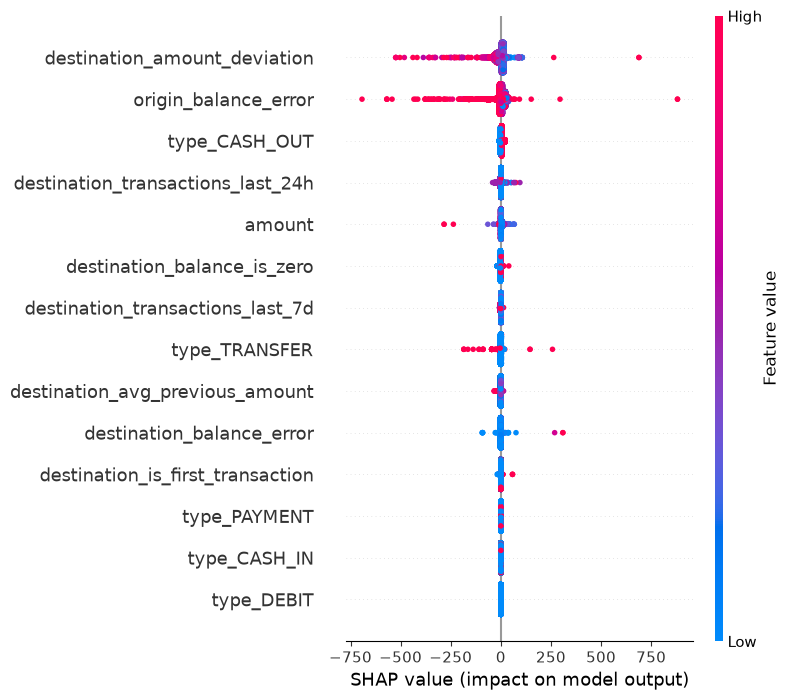

In [17]:
import shap

explainer = shap.TreeExplainer(lgb_delay_aware)

# General population sample
sample_size = 20000
np.random.seed(42)
sample_idx = np.random.choice(X_test_delay.index, size=sample_size, replace=False)
X_shap_sample = X_test_delay.loc[sample_idx]

shap_values = explainer.shap_values(X_shap_sample)
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
else:
    shap_values_fraud = shap_values

shap.summary_plot(shap_values_fraud, X_shap_sample, show=True)

c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Anushka\AppData\Local\Temp\ipykernel_4864\2607333171.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fraud_only, X_shap_fraud, show=True)


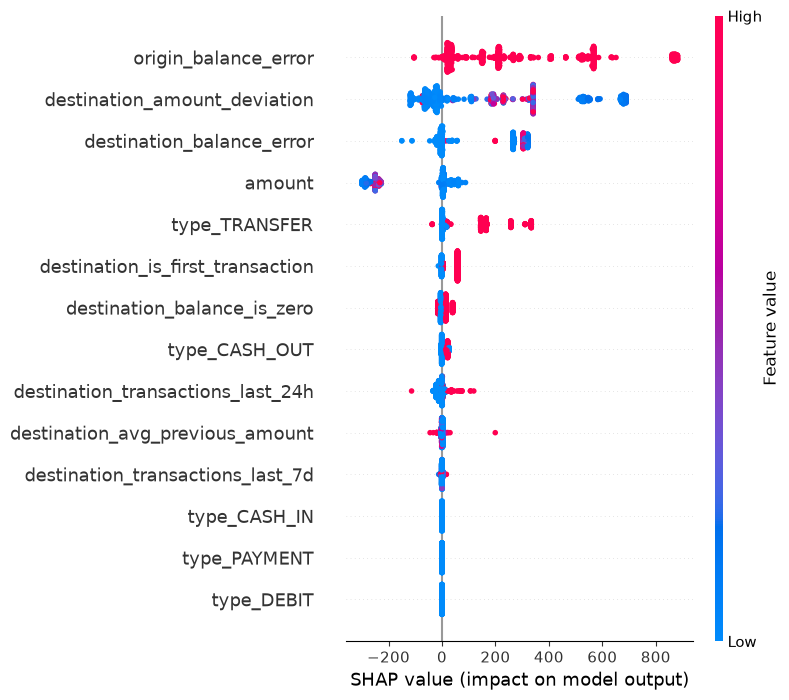

In [18]:
# Fraud-only sample — this is the one that matters more, per your earlier finding
fraud_idx = y_test_delay[y_test_delay == 1].index
X_shap_fraud = X_test_delay.loc[fraud_idx]

shap_values_fraud_only = explainer.shap_values(X_shap_fraud)
if isinstance(shap_values_fraud_only, list):
    shap_values_fraud_only = shap_values_fraud_only[1]

shap.summary_plot(shap_values_fraud_only, X_shap_fraud, show=True)

In [19]:
# Find the transaction(s) driving that extreme SHAP value on origin_balance_error
extreme_idx = np.argmax(np.abs(shap_values_fraud[:, X_shap_sample.columns.get_loc('origin_balance_error')]))
print(X_shap_sample.iloc[extreme_idx])
print(f"SHAP value: {shap_values_fraud[extreme_idx, X_shap_sample.columns.get_loc('origin_balance_error')]}")

amount                               1595587.46
destination_transactions_last_24h           0.0
destination_transactions_last_7d            0.0
destination_avg_previous_amount             0.0
destination_amount_deviation         1595587.46
destination_is_first_transaction              1
origin_balance_error                        0.0
destination_balance_error            1595587.46
destination_balance_is_zero                   1
type_CASH_IN                              False
type_CASH_OUT                             False
type_DEBIT                                False
type_PAYMENT                              False
type_TRANSFER                              True
Name: 5545405, dtype: object
SHAP value: 881.2386181362839
